In [ ]:

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from google.colab import drive
drive.mount('/content/drive')


# ── 1. LOAD ───────────────────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/Data Sets Capstone/research_data/retail_sales_price_revenue_monthly_all_states.csv')
df['period'] = pd.to_datetime(df['period'], format='%Y-%m')
df['year']   = df['period'].dt.year
df['month']  = df['period'].dt.month

# ── 2. SEPARATE AGGREGATES FROM STATES ───────────────────────────────
census_codes = ['ENC','ESC','MAT','MTN','NEW','PACC','PACN','SAT','WNC','WSC','US']
df_national  = df[df['stateid'].isin(census_codes)].copy()   # keep for macro plots
df_states    = df[~df['stateid'].isin(census_codes)].copy()  # primary modeling dataset

# ── 3. DROP STRUCTURALLY MISSING SECTORS ─────────────────────────────
# 'other' and 'transportation' are incomplete across all states/years
drop_sectors = ['other', 'transportation']
df_clean = df_states[~df_states['sectorName'].isin(drop_sectors)].copy()

# ── 4. DROP UNIT COLUMNS (redundant metadata) ─────────────────────────
df_clean = df_clean.drop(columns=['customers-units','price-units',
                                   'revenue-units','sales-units'])

# ── 5. FLAG REMAINING NULLS ───────────────────────────────────────────
# customers has some nulls — flag but don't drop (not needed for price modeling)
df_clean['customers_missing'] = df_clean['customers'].isnull().astype(int)

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Sectors retained: {df_clean['sectorName'].unique()}")
print(f"Null prices remaining: {df_clean['price'].isnull().sum()}")
print(f"States: {df_clean['stateid'].nunique()}")

Mounted at /content/drive
Clean dataset shape: (61200, 12)
Sectors retained: ['all sectors' 'commercial' 'industrial' 'residential']
Null prices remaining: 0
States: 51


In [ ]:
# ── 6. EDA VISUALIZATIONS ─────────────────────────────────────────────

# Plot 1: National average commercial price over time
comm_national = (df_clean[df_clean['sectorName']=='commercial']
                 .groupby('year')['price'].mean().reset_index())

fig1 = px.line(comm_national, x='year', y='price',
               title='National Avg Commercial Electricity Price (2001–2025)',
               labels={'price': '¢/kWh', 'year': 'Year'})
fig1.add_vline(x=2022, line_dash='dash', line_color='red',
               annotation_text='AI Boom', annotation_position='top right')
fig1.update_layout(template='plotly_dark')
fig1.show()

In [ ]:
# Plot 2: Price by sector over time
sector_trend = (df_clean[df_clean['sectorName'].isin(['commercial','residential','industrial'])]
                .groupby(['year','sectorName'])['price'].mean().reset_index())

fig2 = px.line(sector_trend, x='year', y='price', color='sectorName',
               title='Electricity Price by Sector (2001–2025)',
               labels={'price': '¢/kWh', 'sectorName': 'Sector'})
fig2.add_vline(x=2022, line_dash='dash', line_color='red',
               annotation_text='AI Boom', annotation_position='top right')
fig2.update_layout(template='plotly_dark')
fig2.show()

In [ ]:
# Plot 3: Commercial price by state — most recent year
latest_year = df_clean['year'].max()
state_latest = (df_clean[(df_clean['sectorName']=='commercial') &
                          (df_clean['year']==latest_year)]
                .groupby('stateid')['price'].mean().reset_index())

fig3 = px.choropleth(state_latest, locations='stateid',
                     locationmode='USA-states', color='price',
                     scope='usa', color_continuous_scale='Reds',
                     title=f'Commercial Electricity Price by State ({latest_year})',
                     labels={'price': '¢/kWh'})
fig3.update_layout(template='plotly_dark')
fig3.show()

In [ ]:
# Plot 4: Price distribution by sector — boxplot
fig4 = px.box(df_clean[df_clean['sectorName'].isin(['commercial','residential','industrial'])],
              x='sectorName', y='price', color='sectorName',
              title='Price Distribution by Sector (All States, 2001–2025)',
              labels={'price': '¢/kWh', 'sectorName': 'Sector'})
fig4.update_layout(template='plotly_dark')
fig4.show()

In [ ]:
# Plot 5: Top 10 most expensive states for commercial power (most recent year)
top_states = state_latest.sort_values('price', ascending=False).head(10)

fig5 = px.bar(top_states, x='price', y='stateid', orientation='h',
              title=f'Most Expensive States for Commercial Electricity ({latest_year})',
              labels={'price': '¢/kWh', 'stateid': 'State'},
              color='price', color_continuous_scale='Reds')
fig5.update_layout(yaxis={'autorange': 'reversed'}, template='plotly_dark')
fig5.show()

In [ ]:
# Plot 6: Highest Year-over-Year % increase in electricity prices for each state and sector

# Calculate yearly average price per state and sector, excluding 'all sectors'
yearly_avg_price = df_clean[df_clean['sectorName'].isin(['residential', 'commercial'])].groupby(['stateid', 'sectorName', 'year'])['price'].mean().reset_index()

# Filter data to include only years since 2010
yearly_avg_price = yearly_avg_price[yearly_avg_price['year'] >= 2010]

# Calculate year-over-year percentage change in price
yearly_avg_price['price_yoy_pct_change'] = yearly_avg_price.groupby(['stateid', 'sectorName'])['price'].pct_change() * 100

# Remove NaN values resulting from pct_change (first year for each state-sector group)
yearly_avg_price.dropna(subset=['price_yoy_pct_change'], inplace=True)

# Find the maximum year-over-year percentage increase for each state and sector combination
max_yoy_increase = yearly_avg_price.loc[yearly_avg_price.groupby(['stateid', 'sectorName'])['price_yoy_pct_change'].idxmax()]

# Sort by the highest percentage increase to identify the top events
max_yoy_increase = max_yoy_increase.sort_values(by='price_yoy_pct_change', ascending=False)

# Select top N for visualization (e.g., top 20 increases)
top_n = 20
top_increases_plot = max_yoy_increase.head(top_n).copy() # Added .copy() here

# Create a combined state and sector label for the y-axis for better readability
top_increases_plot['state_sector'] = top_increases_plot['stateid'] + ' - ' + top_increases_plot['sectorName']

# Create a new column to display both percentage and year on the bars
top_increases_plot['display_text'] = top_increases_plot.apply(
    lambda row: f"{row['price_yoy_pct_change']:.1f}% ({row['year']})", axis=1
)

# Create the horizontal bar chart
fig6 = px.bar(top_increases_plot,
              x='price_yoy_pct_change',
              y='state_sector',
              orientation='h',
              title=f'Top {top_n} Highest YoY Electricity Price Increases (Residential & Commercial) since 2010',
              labels={'price_yoy_pct_change': 'YoY % Increase in Price', 'state_sector': 'State - Sector'},
              color='price_yoy_pct_change',
              color_continuous_scale='Plasma',
              text='display_text', # Use the new column for text
              hover_data={'year':True, 'price_yoy_pct_change':':.2f', 'price':':.2f'})

# Reverse y-axis to have the highest increase at the top of the chart
fig6.update_layout(
    yaxis={'autorange': 'reversed'},
    width=900, # Increase width for better text visibility
    template="plotly_dark"
)
# Display text outside the bars for better readability
fig6.update_traces(textposition='outside')
fig6.show()

In [ ]:
# Plot 7: Highest Year-over-Year % increase in electricity prices for states with data centers

# Define states commonly known for significant data center presence
data_center_states = ['VA', 'OR', 'TX', 'CA', 'IL', 'NY', 'GA', 'AZ', 'WA', 'NC', 'OH', 'NV', 'UT']

# Filter the max_yoy_increase (calculated in Plot 6) for these states
data_center_yoy_increase = max_yoy_increase[max_yoy_increase['stateid'].isin(data_center_states)].copy()

# Sort by the highest percentage increase and select top N for visualization
top_n_dc = 20 # Adjust as needed
top_increases_dc_plot = data_center_yoy_increase.sort_values(by='price_yoy_pct_change', ascending=False).head(top_n_dc)

# Create a combined state and sector label for the y-axis
top_increases_dc_plot['state_sector'] = top_increases_dc_plot['stateid'] + ' - ' + top_increases_dc_plot['sectorName']

# Create a new column to display both percentage and year on the bars
top_increases_dc_plot['display_text'] = top_increases_dc_plot.apply(
    lambda row: f"{row['price_yoy_pct_change']:.1f}% ({row['year']})", axis=1
)

# Create the horizontal bar chart
fig7 = px.bar(top_increases_dc_plot,
              x='price_yoy_pct_change',
              y='state_sector',
              orientation='h',
              title=f'Top {top_n_dc} YoY Price Increases in Data Center States (Residential & Commercial) since 2010',
              labels={'price_yoy_pct_change': 'YoY % Increase in Price', 'state_sector': 'State - Sector'},
              color='price_yoy_pct_change',
              color_continuous_scale='Plasma', # Using the Plasma scale again
              text='display_text',
              hover_data={'year':True, 'price_yoy_pct_change':':.2f', 'price':':.2f'})

# Reverse y-axis and update layout
fig7.update_layout(
    yaxis={'autorange': 'reversed'},
    width=900,
    template='plotly_dark'
)
fig7.update_traces(textposition='outside')
fig7.show()

In [ ]:
fig_hist = px.histogram(df_clean, x='price',
                        title='Distribution of Electricity Prices (All Sectors and States)',
                        labels={'price': 'Price (¢/kWh)', 'count': 'Frequency'},
                        nbins=50) # You can adjust nbins for more or fewer bars
fig_hist.update_layout(bargap=0.1, template='plotly_dark') # Add some gap between bars for better visualization
fig_hist.show()

In [ ]:
# Histogram for 2010-2020
df_2010_2020 = df_clean[(df_clean['year'] >= 2010) & (df_clean['year'] <= 2021)]
fig_hist_2010_2020 = px.histogram(df_2010_2020, x='price',
                                title='Distribution of Electricity Prices (2010-2021)',
                                labels={'price': 'Price (¢/kWh)', 'count': 'Frequency'},
                                nbins=50)
fig_hist_2010_2020.update_layout(bargap=0.1, template='plotly_dark')
fig_hist_2010_2020.show()

In [ ]:
# Histogram for 2021-2025
df_2021_2025 = df_clean[(df_clean['year'] >= 2022) & (df_clean['year'] <= 2025)]
fig_hist_2021_2025 = px.histogram(df_2021_2025, x='price',
                                title='Distribution of Electricity Prices (2022-2025)',
                                labels={'price': 'Price (¢/kWh)', 'count': 'Frequency'},
                                nbins=50)
fig_hist_2021_2025.update_layout(bargap=0.1, template='plotly_dark')
fig_hist_2021_2025.show()

Once `kaleido` is installed, you can use `fig.write_image()` for any of your generated Plotly figures. For example, to save `fig_avg_yoy` (the bar chart showing average year-over-year price increases), you would do the following:

In [ ]:
# Example: Save fig_avg_yoy as a PNG
fig_avg_yoy.write_image("average_yoy_price_increase.png")
print("Saved average_yoy_price_increase.png")

# You can do this for any of your figures, e.g., fig1, fig2, fig3, etc.
# fig1.write_image("national_commercial_price.png")
# fig2.write_image("price_by_sector.png")
# fig3.write_image("commercial_price_by_state.png")
# fig4.write_image("price_distribution_by_sector.png")
# fig5.write_image("most_expensive_states.png")
# fig6.write_image("top_yoy_increase.png")
# fig7.write_image("data_center_states_yoy_increase.png")
# fig_hist.write_image("price_distribution_all_time.png")
# fig_hist_2010_2020.write_image("price_distribution_2010_2020.png")
# fig_hist_2021_2025.write_image("price_distribution_2021_2025.png")

NameError: name 'fig_avg_yoy' is not defined

In [ ]:
pip install nest_asyncio

In [ ]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
import asyncio
import kaleido

async def install_chrome():
    await kaleido.get_chrome()

asyncio.run(install_chrome())

In [ ]:
!sudo apt update && sudo apt-get install -y libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

After running this code, you will find the `average_yoy_price_increase.png` file in your Colab environment's file browser (usually on the left sidebar). You can then download it from there.

In [ ]:
import plotly.express as px

# Calculate the average year-over-year percentage change for each year
avg_yoy_yearly = yearly_avg_price.groupby('year')['price_yoy_pct_change'].mean().reset_index()

# Create the bar chart
fig_avg_yoy = px.bar(avg_yoy_yearly,
                     x='year',
                     y='price_yoy_pct_change',
                     title='Average Year-over-Year Electricity Price Increase by Year (All States & Sectors)',
                     labels={'price_yoy_pct_change': 'Average YoY % Increase', 'year': 'Year'},
                     color='price_yoy_pct_change',
                     color_continuous_scale='Viridis') # Using a different color scale for variety

fig_avg_yoy.update_layout(template='plotly_dark')
fig_avg_yoy.show()

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import pandas as pd
import numpy as np


Train: 2001-01-01 → 2022-12-01 (264 months)
Test:  2023-01-01 → 2025-12-01 (36 months)
States: 51
Datacenter regressor range: 0 – 72348 MW
AK | commercial   — MAE: 0.952  MAPE: 4.32%
AL | commercial   — MAE: 0.585  MAPE: 4.14%
AR | commercial   — MAE: 0.686  MAPE: 6.59%
AZ | commercial   — MAE: 1.572  MAPE: 13.00%
CA | commercial   — MAE: 1.685  MAPE: 6.73%
CO | commercial   — MAE: 0.293  MAPE: 2.49%
CT | commercial   — MAE: 3.130  MAPE: 14.05%
DC | commercial   — MAE: 2.141  MAPE: 11.32%
DE | commercial   — MAE: 1.502  MAPE: 12.19%
FL | commercial   — MAE: 0.634  MAPE: 5.44%
GA | commercial   — MAE: 1.650  MAPE: 15.12%
HI | commercial   — MAE: 3.799  MAPE: 10.22%
IA | commercial   — MAE: 0.505  MAPE: 4.93%
ID | commercial   — MAE: 0.736  MAPE: 7.98%
IL | commercial   — MAE: 0.535  MAPE: 4.29%
IN | commercial   — MAE: 0.732  MAPE: 5.80%
KS | commercial   — MAE: 0.408  MAPE: 3.72%
KY | commercial   — MAE: 0.808  MAPE: 7.00%
LA | commercial   — MAE: 1.917  MAPE: 18.13%
MA | commercial   

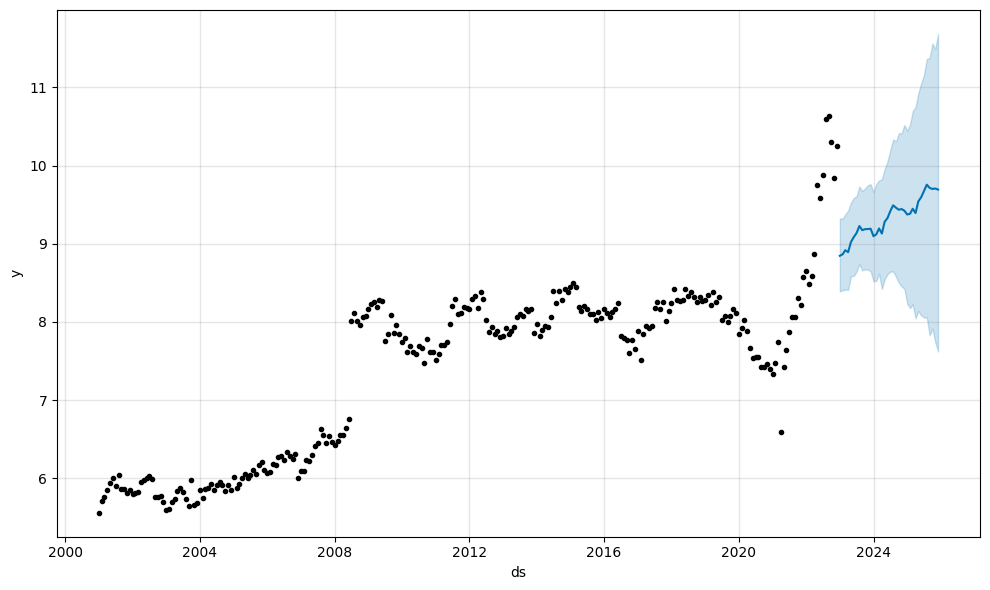

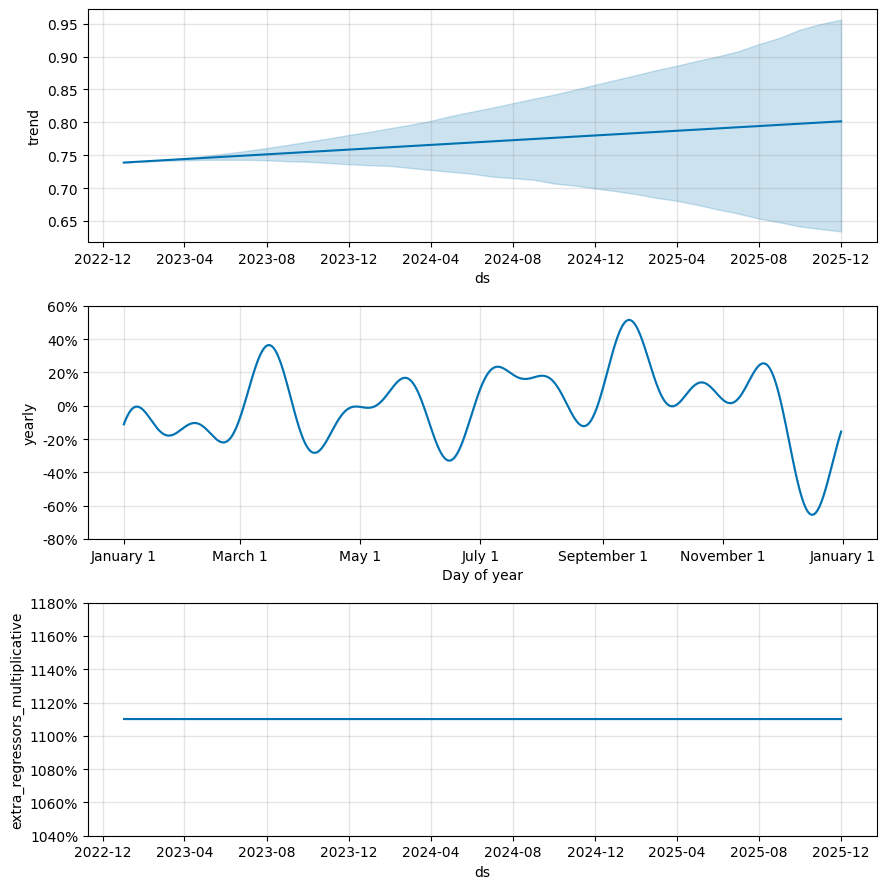

In [ ]:
df['period'] = pd.to_datetime(df['period'], format='%Y-%m')

census_codes = ['ENC','ESC','MAT','MTN','NEW','PACC','PACN','SAT','WNC','WSC','US']
drop_sectors  = ['other','transportation']
df_clean = df[~df['stateid'].isin(census_codes) & ~df['sectorName'].isin(drop_sectors)].copy()
df_model = df_clean[df_clean['sectorName'].isin(['commercial','residential'])].copy()
df_model = df_model.sort_values(['stateid','sectorName','period']).reset_index(drop=True)

# ── 2. ADD DATACENTER MW AS REGRESSOR ────────────────────────────────
fac = pd.read_csv('/content/drive/MyDrive/Data Sets Capstone/research_data/facilities_cleaned (1).csv')
dc_by_state = (fac.groupby('STATE_CODE')['TOT_POWER_MW']
                  .sum()
                  .reset_index()
                  .rename(columns={'STATE_CODE':'stateid','TOT_POWER_MW':'dc_mw'}))

df_model = df_model.merge(dc_by_state, on='stateid', how='left')
df_model['dc_mw'] = df_model['dc_mw'].fillna(0)
df_model['dc_mw_norm'] = (df_model['dc_mw'] - df_model['dc_mw'].mean()) / df_model['dc_mw'].std()

# ── 3. TRAIN / TEST SPLIT ─────────────────────────────────────────────
train_df = df_model[df_model['period'] < '2023-01-01'].copy()
test_df  = df_model[df_model['period'] >= '2023-01-01'].copy()

print(f"Train: {train_df['period'].min().date()} → {train_df['period'].max().date()} ({train_df['period'].nunique()} months)")
print(f"Test:  {test_df['period'].min().date()} → {test_df['period'].max().date()} ({test_df['period'].nunique()} months)")
print(f"States: {df_model['stateid'].nunique()}")
print(f"Datacenter regressor range: {df_model['dc_mw'].min():.0f} – {df_model['dc_mw'].max():.0f} MW")
# ── 4. PROPHET HELPER FUNCTION ────────────────────────────────────────
# Wraps the Prophet workflow for a single state
# Returns the fitted model, forecast df, MAE, and MAPE

def fit_prophet(state_code, sector='commercial', use_dc_regressor=True):

    state_train = train_df[
        (train_df['stateid'] == state_code) &
        (train_df['sectorName'] == sector)
    ][['period','price','dc_mw_norm']].copy()

    state_test = test_df[
        (test_df['stateid'] == state_code) &
        (test_df['sectorName'] == sector)
    ][['period','price','dc_mw_norm']].copy()
    # Prophet expects columns named 'ds' and 'y'
    state_train = state_train.rename(columns={'period':'ds','price':'y'})
    state_test  = state_test.rename(columns={'period':'ds','price':'y'})

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,   # monthly data — no weekly pattern
        daily_seasonality=False,
        seasonality_mode='multiplicative',  # better for growing series
        changepoint_prior_scale=0.1,        # controls trend flexibility
    )

    if use_dc_regressor:
        m.add_regressor('dc_mw_norm')

    m.fit(state_train)

    # Forecast over test period
    future = state_test[['ds','dc_mw_norm']].copy() if use_dc_regressor else state_test[['ds']].copy()
    forecast = m.predict(future)

    # Evaluate
    y_true = state_test['y'].values
    y_pred = forecast['yhat'].values
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return m, forecast, state_test, mae, mape

results = []

for sector in ['commercial', 'residential']:
    for state in sorted(df_model['stateid'].unique()):

        m, forecast, state_test, mae, mape = fit_prophet(
            state_code=state,
            sector=sector,           # pass sector in too — see note below
            use_dc_regressor=True
        )

        results.append({
            'state':   state,
            'sector':  sector,
            'mae':     round(mae, 3),
            'mape':    round(mape, 2),
        })

        print(f"{state} | {sector:12s} — MAE: {mae:.3f}  MAPE: {mape:.2f}%")

results_df = pd.DataFrame(results)
print(results_df)
# ── 5. QUICK SANITY CHECK ON ONE STATE ───────────────────────────────
# Run on Virginia first — most important datacenter state
m_va, fc_va, test_va, mae_va, mape_va = fit_prophet('VA')

print(f"Virginia — MAE: {mae_va:.3f}¢/kWh  |  MAPE: {mape_va:.2f}%")
print(fc_va[['ds','yhat','yhat_lower','yhat_upper']].tail(6))
# ── 6. PLOT PROPHET COMPONENTS ───────────────────────────────────────
# Shows trend, yearly seasonality decomposed
fig1 = m_va.plot(fc_va)
fig2 = m_va.plot_components(fc_va)

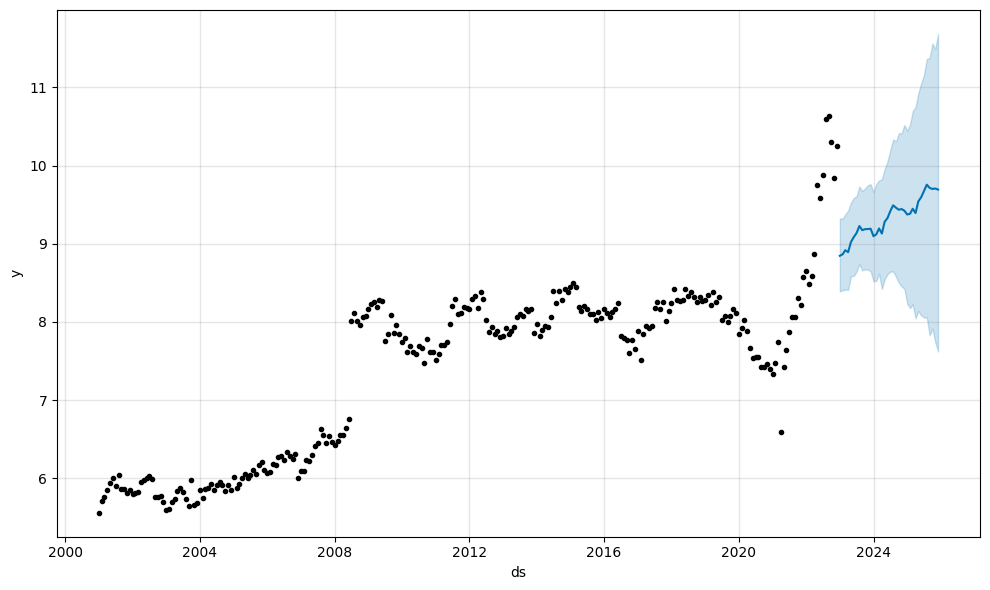

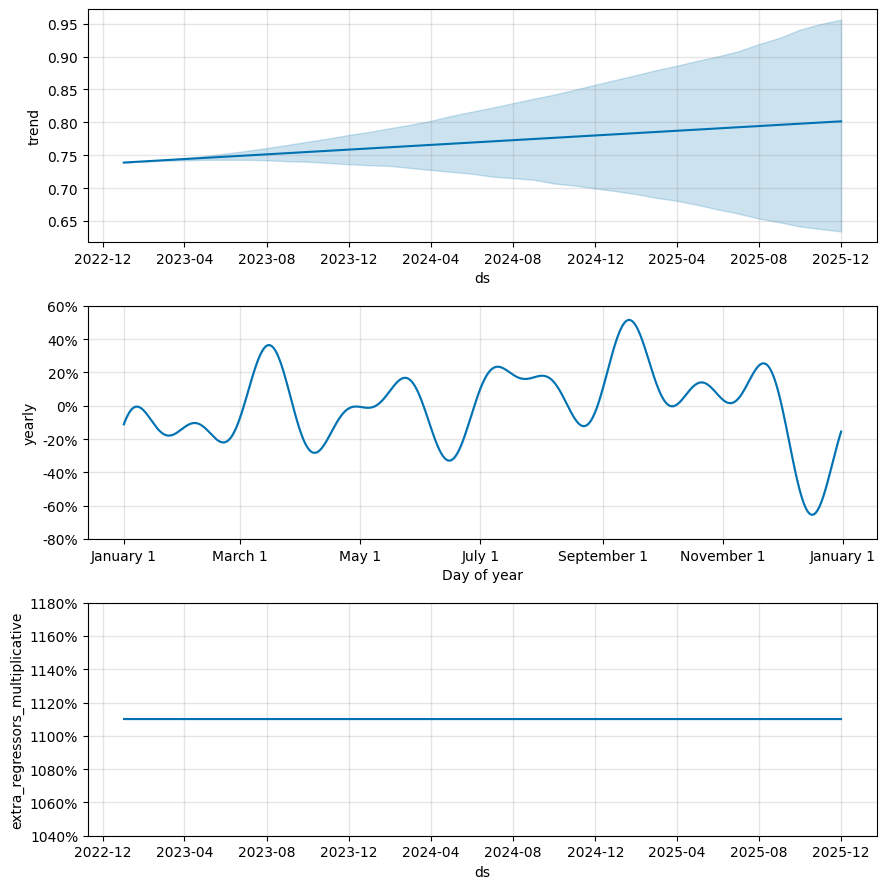

In [ ]:
fig1 = m_va.plot(fc_va)
fig2 = m_va.plot_components(fc_va)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

results = []

for sector in ['commercial', 'residential']:
    for state in sorted(df_model['stateid'].unique()):
        try:
            m, forecast, state_test, mae, mape = fit_prophet(
                state_code=state,
                sector=sector,
                use_dc_regressor=True
            )

            results.append({
                'state':  state,
                'sector': sector,
                'mae':    round(mae, 3),
                'mape':   round(mape, 2),
            })

            print(f"{state} | {sector:12s} — MAE: {mae:.3f}  MAPE: {mape:.2f}%")

        except Exception as e:
            print(f"{state} | {sector:12s} — ERROR: {e}")
            results.append({
                'state':  state,
                'sector': sector,
                'mae':    None,
                'mape':   None,
            })

results_df = pd.DataFrame(results)
print("\n── Summary ──────────────────────────────")
print(results_df.groupby('sector')[['mae','mape']].describe().round(3))

AK | commercial   — MAE: 0.952  MAPE: 4.32%
AL | commercial   — MAE: 0.585  MAPE: 4.14%
AR | commercial   — MAE: 0.686  MAPE: 6.59%
AZ | commercial   — MAE: 1.572  MAPE: 13.00%
CA | commercial   — MAE: 1.685  MAPE: 6.73%
CO | commercial   — MAE: 0.293  MAPE: 2.49%
CT | commercial   — MAE: 3.130  MAPE: 14.05%
DC | commercial   — MAE: 2.141  MAPE: 11.32%
DE | commercial   — MAE: 1.502  MAPE: 12.19%
FL | commercial   — MAE: 0.634  MAPE: 5.44%
GA | commercial   — MAE: 1.650  MAPE: 15.12%
HI | commercial   — MAE: 3.799  MAPE: 10.22%
IA | commercial   — MAE: 0.505  MAPE: 4.93%
ID | commercial   — MAE: 0.736  MAPE: 7.98%
IL | commercial   — MAE: 0.535  MAPE: 4.29%
IN | commercial   — MAE: 0.732  MAPE: 5.80%
KS | commercial   — MAE: 0.408  MAPE: 3.72%
KY | commercial   — MAE: 0.808  MAPE: 7.00%
LA | commercial   — MAE: 1.917  MAPE: 18.13%
MA | commercial   — MAE: 2.764  MAPE: 12.59%
MD | commercial   — MAE: 1.176  MAPE: 8.35%
ME | commercial   — MAE: 3.936  MAPE: 20.29%
MI | commercial   — MAE

In [ ]:
print("Worst commercial MAE:")
print(results_df[results_df['sector']=='commercial'].nlargest(5,'mae')[['state','mae','mape']])

print("\nWorst residential MAE:")
print(results_df[results_df['sector']=='residential'].nlargest(5,'mae')[['state','mae','mape']])

Worst commercial MAE:
   state    mae   mape
39    RI  5.177  23.12
21    ME  3.936  20.29
11    HI  3.799  10.22
6     CT  3.130  14.05
19    MA  2.764  12.59

Worst residential MAE:
   state    mae   mape
58    DC  4.577  23.21
72    ME  4.334  15.84
57    CT  4.102  13.39
71    MD  3.687  19.99
90    RI  3.520  11.84


In [ ]:
problem_states = ['RI', 'ME', 'CT', 'MA', 'DC', 'MD']

results_refined = []

for sector in ['commercial', 'residential']:
    for state in problem_states:
        try:
            # Override changepoint_prior_scale for these states
            state_train = train_df[
                (train_df['stateid'] == state) &
                (train_df['sectorName'] == sector)
            ][['period','price','dc_mw_norm']].copy()

            state_test = test_df[
                (test_df['stateid'] == state) &
                (test_df['sectorName'] == sector)
            ][['period','price','dc_mw_norm']].copy()

            state_train = state_train.rename(columns={'period':'ds','price':'y'})
            state_test  = state_test.rename(columns={'period':'ds','price':'y'})

            m = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                changepoint_prior_scale=0.5,   # more flexible for volatile states
                changepoints=['2022-01-01'],
            )
            m.add_regressor('dc_mw_norm')
            m.fit(state_train)

            future = state_test[['ds','dc_mw_norm']].copy()
            forecast = m.predict(future)

            y_true = state_test['y'].values
            y_pred = forecast['yhat'].values
            mae  = mean_absolute_error(y_true, y_pred)
            mape = mean_absolute_percentage_error(y_true, y_pred) * 100

            results_refined.append({
                'state': state, 'sector': sector,
                'mae': round(mae,3), 'mape': round(mape,2)
            })
            print(f"{state} | {sector:12s} — MAE: {mae:.3f}  MAPE: {mape:.2f}%")

        except Exception as e:
            print(f"{state} | {sector} — ERROR: {e}")

refined_df = pd.DataFrame(results_refined)
print(refined_df)

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


RI | commercial   — MAE: 3.902  MAPE: 17.39%
ME | commercial   — MAE: 2.229  MAPE: 11.55%
CT | commercial   — MAE: 2.381  MAPE: 10.55%
MA | commercial   — MAE: 1.022  MAPE: 4.96%


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


DC | commercial   — MAE: 2.708  MAPE: 14.91%
MD | commercial   — MAE: 2.261  MAPE: 16.81%
RI | residential  — MAE: 2.835  MAPE: 10.11%


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


ME | residential  — MAE: 11.873  MAPE: 45.55%


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


CT | residential  — MAE: 4.250  MAPE: 13.90%
MA | residential  — MAE: 9.838  MAPE: 32.93%


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


DC | residential  — MAE: 3.602  MAPE: 17.94%
MD | residential  — MAE: 2.131  MAPE: 11.35%
   state       sector     mae   mape
0     RI   commercial   3.902  17.39
1     ME   commercial   2.229  11.55
2     CT   commercial   2.381  10.55
3     MA   commercial   1.022   4.96
4     DC   commercial   2.708  14.91
5     MD   commercial   2.261  16.81
6     RI  residential   2.835  10.11
7     ME  residential  11.873  45.55
8     CT  residential   4.250  13.90
9     MA  residential   9.838  32.93
10    DC  residential   3.602  17.94
11    MD  residential   2.131  11.35


In [ ]:
for _, row in refined_df.iterrows():
    mask = (results_df['state']==row['state']) & (results_df['sector']==row['sector'])
    results_df.loc[mask, ['mae','mape']] = [row['mae'], row['mape']]

In [ ]:
# Commercial — swap all 6
commercial_keep = ['RI','ME','CT','MA','DC','MD']

# Residential — swap only these 3
residential_keep = ['RI','DC','MD']

for _, row in refined_df.iterrows():
    if row['sector'] == 'commercial' and row['state'] in commercial_keep:
        mask = (results_df['state']==row['state']) & (results_df['sector']=='commercial')
        results_df.loc[mask, ['mae','mape']] = [row['mae'], row['mape']]
    elif row['sector'] == 'residential' and row['state'] in residential_keep:
        mask = (results_df['state']==row['state']) & (results_df['sector']=='residential')
        results_df.loc[mask, ['mae','mape']] = [row['mae'], row['mape']]

# Verify final summary
print(results_df.groupby('sector')[['mae','mape']].describe().round(3))

              mae                                                    mape  \
            count   mean    std    min    25%    50%    75%     max count   
sector                                                                      
commercial   51.0  1.082  0.803  0.228  0.609  0.808  1.263   3.902  51.0   
residential  51.0  1.811  2.090  0.229  0.684  1.239  2.152  11.873  51.0   

                                                             
              mean    std   min    25%   50%     75%    max  
sector                                                       
commercial   7.882  4.329  2.15  4.735  6.73  10.515  18.13  
residential  9.386  7.559  1.18  4.450  7.85  12.050  45.55  


In [ ]:
results_df.to_csv('prophet_model_results.csv', index=False)

In [ ]:
# ── FULL DATASET RETRAIN + FORECAST TO 2028 ───────────────────────────

forecasts_full = []

for sector in ['commercial', 'residential']:
    for state in sorted(df_model['stateid'].unique()):
        try:
            full_data = df_model[
                (df_model['stateid'] == state) &
                (df_model['sectorName'] == sector)
            ][['period','price','dc_mw_norm']].copy()

            full_data = full_data.rename(columns={'period':'ds','price':'y'})

            # Use refined scale for problem states, standard for everyone else
            commercial_refined = ['RI','ME','CT','MA','DC','MD']
            residential_refined = ['RI','DC','MD']

            if (sector=='commercial' and state in commercial_refined) or \
               (sector=='residential' and state in residential_refined):
                cps = 0.5
                cpts = ['2022-01-01']
            else:
                cps = 0.1
                cpts = None

            m = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                changepoint_prior_scale=cps,
                changepoints=cpts,
            )
            m.add_regressor('dc_mw_norm')
            m.fit(full_data)

            # 36 months beyond end of data = through Dec 2028
            future = m.make_future_dataframe(periods=36, freq='MS')
            dc_val = full_data['dc_mw_norm'].iloc[0]
            future['dc_mw_norm'] = dc_val

            forecast = m.predict(future)

            # Tag and store
            forecast['state']  = state
            forecast['sector'] = sector
            forecasts_full.append(forecast[['ds','state','sector',
                                            'yhat','yhat_lower','yhat_upper']])

            print(f"✓ {state} | {sector}")

        except Exception as e:
            print(f"✗ {state} | {sector} — ERROR: {e}")

forecast_df = pd.concat(forecasts_full, ignore_index=True)
forecast_df = forecast_df.rename(columns={'ds':'period'})
forecast_df['period'] = pd.to_datetime(forecast_df['period'])
print(f"\nForecast dataframe shape: {forecast_df.shape}")
print(forecast_df.head())

✓ AK | commercial
✓ AL | commercial
✓ AR | commercial
✓ AZ | commercial
✓ CA | commercial
✓ CO | commercial
✓ CT | commercial
✓ DC | commercial
✓ DE | commercial
✓ FL | commercial
✓ GA | commercial
✓ HI | commercial
✓ IA | commercial
✓ ID | commercial
✓ IL | commercial
✓ IN | commercial
✓ KS | commercial
✓ KY | commercial
✓ LA | commercial
✓ MA | commercial
✓ MD | commercial
✓ ME | commercial
✓ MI | commercial
✓ MN | commercial
✓ MO | commercial
✓ MS | commercial
✓ MT | commercial
✓ NC | commercial
✓ ND | commercial
✓ NE | commercial
✓ NH | commercial
✓ NJ | commercial
✓ NM | commercial
✓ NV | commercial
✓ NY | commercial
✓ OH | commercial
✓ OK | commercial
✓ OR | commercial
✓ PA | commercial
✓ RI | commercial
✓ SC | commercial
✓ SD | commercial
✓ TN | commercial
✓ TX | commercial
✓ UT | commercial
✓ VA | commercial
✓ VT | commercial
✓ WA | commercial
✓ WI | commercial
✓ WV | commercial
✓ WY | commercial
✓ AK | residential
✓ AL | residential
✓ AR | residential
✓ AZ | residential
✓ CA |

In [ ]:
# ── SEPARATE HISTORICAL FIT FROM FUTURE FORECAST ─────────────────────

# Everything after Dec 2025 is the true forward forecast
future_only = forecast_df[forecast_df['period'] > '2025-12-01'].copy()
historical_fit = forecast_df[forecast_df['period'] <= '2025-12-01'].copy()

print(f"Historical fitted values: {historical_fit.shape}")
print(f"Future forecast (2026-2028): {future_only.shape}")

# Save both
forecast_df.to_csv('prophet_forecast_full.csv', index=False)
future_only.to_csv('prophet_forecast_2026_2028.csv', index=False)
print("\nSaved forecast files.")

Historical fitted values: (30600, 6)
Future forecast (2026-2028): (3672, 6)

Saved forecast files.


In [ ]:
# ── 2028 PROJECTED PRICES FOR KEY DATACENTER STATES ──────────────────

key_states = ['VA','TX','GA','NV','AZ','PA','OH','IL']

dec_2028 = future_only[
    (future_only['period'] == '2028-12-01') &
    (future_only['sector'] == 'commercial') &
    (future_only['state'].isin(key_states))
][['state','yhat','yhat_lower','yhat_upper']].sort_values('yhat', ascending=False)

dec_2028.columns = ['state','projected_¢/kWh','lower_bound','upper_bound']
dec_2028 = dec_2028.round(2)
print("Projected commercial electricity prices — December 2028:")
print(dec_2028.to_string(index=False))


Projected commercial electricity prices — December 2028:
state  projected_¢/kWh  lower_bound  upper_bound
   PA            14.83        14.15        15.48
   IL            14.69        13.85        15.50
   AZ            13.58        13.02        14.11
   OH            12.56        11.84        13.27
   NV            12.18        11.19        13.25
   GA            11.78        11.08        12.48
   VA            10.71         8.95        12.51
   TX             8.53         6.39        10.90


In [ ]:
import plotly.graph_objects as go

# ── DATA ──────────────────────────────────────────────────────────────
key_states = ['VA','TX','GA','NV','AZ','PA','OH','IL']

dec_2028 = future_only[
    (future_only['period'] == '2028-12-01') &
    (future_only['sector'] == 'commercial') &
    (future_only['state'].isin(key_states))
][['state','yhat','yhat_lower','yhat_upper']].sort_values('yhat', ascending=True)

# DC MW for color coding
dc_lookup = dc_by_state.set_index('stateid')['dc_mw'].to_dict()
dec_2028['dc_mw'] = dec_2028['state'].map(dc_lookup)

# ── CHART ─────────────────────────────────────────────────────────────
fig = go.Figure()

# Uncertainty bands as horizontal error bars
fig.add_trace(go.Scatter(
    x=dec_2028['yhat'],
    y=dec_2028['state'],
    mode='markers',
    name='Projected Dec 2028',
    marker=dict(
        size=14,
        color=dec_2028['dc_mw'],
        colorscale='Reds',
        colorbar=dict(title='Datacenter MW', x=1.02),
        line=dict(width=1, color='white')
    ),
    error_x=dict(
        type='data',
        symmetric=False,
        array=dec_2028['yhat_upper'] - dec_2028['yhat'],
        arrayminus=dec_2028['yhat'] - dec_2028['yhat_lower'],
        color='rgba(150,150,150,0.5)',
        thickness=2,
        width=6
    ),
    hovertemplate=(
        '<b>%{y}</b><br>' +
        'Projected: %{x:.2f}¢/kWh<br>' +
        'Range: %{customdata[0]:.2f}¢ – %{customdata[1]:.2f}¢<extra></extra>'
    ),
    customdata=dec_2028[['yhat_lower','yhat_upper']].values
))

# National average reference line
nat_avg = dec_2028['yhat'].mean()
fig.add_vline(
    x=nat_avg,
    line_dash='dash',
    line_color='rgba(200,200,200,0.5)',
    annotation_text=f'Group avg: {nat_avg:.2f}¢',
    annotation_position='top'
)

# 2025 actual prices for comparison — vertical reference per state
actual_2025 = df_model[
    (df_model['period'] == '2025-12-01') &
    (df_model['sectorName'] == 'commercial') &
    (df_model['stateid'].isin(key_states))
][['stateid','price']].set_index('stateid')['price'].to_dict()

dec_2028['actual_2025'] = dec_2028['state'].map(actual_2025)

fig.add_trace(go.Scatter(
    x=dec_2028['actual_2025'],
    y=dec_2028['state'],
    mode='markers',
    marker=dict(size=10, symbol='diamond', color='steelblue',
                line=dict(width=1, color='white')),
    name='Actual Dec 2025',
    hovertemplate='<b>%{y}</b> actual Dec 2025: %{x:.2f}¢<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Projected Commercial Electricity Prices — December 2028<br>' +
             '<sup>Circles = 2028 forecast (color = datacenter MW) · Diamonds = Dec 2025 actual · Bars = 80% uncertainty</sup>',
        font=dict(size=16)
    ),
    xaxis=dict(
        title='¢/kWh',
        gridcolor='rgba(255,255,255,0.1)',
        zeroline=False
    ),
    yaxis=dict(
        title='State',
        gridcolor='rgba(255,255,255,0.05)'
    ),
    paper_bgcolor='#0a0c10',
    plot_bgcolor='#111318',
    font_color='white',
    showlegend=True,
    legend=dict(x=0.02, y=0.98),
    height=500,
    margin=dict(r=120)
)

fig.show()
fig.write_html('forecast_2028_uncertainty.html')
print("Saved forecast_2028_uncertainty.html")

Saved forecast_2028_uncertainty.html


In [ ]:
# ── ALL 51 STATES — 2028 PROJECTION ──────────────────────────────────

all_2028 = future_only[
    (future_only['period'] == '2028-12-01') &
    (future_only['sector'] == 'commercial')
][['state','yhat','yhat_lower','yhat_upper']].sort_values('yhat', ascending=True).reset_index(drop=True)

all_2028['dc_mw'] = all_2028['state'].map(dc_lookup).fillna(0)

actual_2025_all = df_model[
    (df_model['period'] == '2025-12-01') &
    (df_model['sectorName'] == 'commercial')
][['stateid','price']].set_index('stateid')['price'].to_dict()

all_2028['actual_2025'] = all_2028['state'].map(actual_2025_all)

# Key datacenter states to highlight
key_states = ['VA','TX','GA','NV','AZ','PA','OH','IL']

fig2 = go.Figure()

# Uncertainty bands
fig2.add_trace(go.Scatter(
    x=all_2028['yhat'],
    y=all_2028['state'],
    mode='markers',
    name='Projected Dec 2028',
        marker=dict(
        size=10,
        color=all_2028['dc_mw'],
        colorscale='Reds',
        cmin=0,
        cmax=all_2028['dc_mw'].max(),
        colorbar=dict(title='Datacenter MW', x=1.02),
        line=dict(
            width=[2 if s in key_states else 0.5 for s in all_2028['state']],
            color=['white' if s in key_states else 'rgba(255,255,255,0.2)'
                   for s in all_2028['state']]
        )
    ),
    error_x=dict(
        type='data',
        symmetric=False,
        array=all_2028['yhat_upper'] - all_2028['yhat'],
        arrayminus=all_2028['yhat'] - all_2028['yhat_lower'],
        color='rgba(150,150,150,0.3)',
        thickness=1.5,
        width=4
    ),
    hovertemplate=(
        '<b>%{y}</b><br>' +
        'Projected: %{x:.2f}¢/kWh<br>' +
        'Range: %{customdata[0]:.2f}¢ – %{customdata[1]:.2f}¢<br>' +
        'Datacenter MW: %{customdata[2]:,.0f}<extra></extra>'
    ),
    customdata=all_2028[['yhat_lower','yhat_upper','dc_mw']].values
))

# Dec 2025 actual diamonds
fig2.add_trace(go.Scatter(
    x=all_2028['actual_2025'],
    y=all_2028['state'],
    mode='markers',
    name='Actual Dec 2025',
    marker=dict(
        size=7,
        symbol='diamond',
        color='steelblue',
        line=dict(width=0.5, color='white')
    ),
    hovertemplate='<b>%{y}</b> actual Dec 2025: %{x:.2f}¢<extra></extra>'
))

# Annotations for key datacenter states
for _, row in all_2028[all_2028['state'].isin(key_states)].iterrows():
    fig2.add_annotation(
        x=row['yhat_upper'] + 0.3,
        y=row['state'],
        text=row['state'],
        showarrow=False,
        font=dict(size=10, color='white'),
        xanchor='left'
    )

# National average line
nat_avg_all = all_2028['yhat'].mean()
fig2.add_vline(
    x=nat_avg_all,
    line_dash='dash',
    line_color='rgba(200,200,200,0.4)',
    annotation_text=f'National avg: {nat_avg_all:.2f}¢',
    annotation_position='top'
)

fig2.update_layout(
    title=dict(
        text='Projected Commercial Electricity Prices — December 2028 · All States<br>' +
             '<sup>Circles = 2028 forecast (color = datacenter MW) · Diamonds = Dec 2025 actual · Key states labeled</sup>',
        font=dict(size=16)
    ),
    xaxis=dict(
        title='¢/kWh',
        gridcolor='rgba(255,255,255,0.08)',
        zeroline=False
    ),
    yaxis=dict(
        title='State',
        tickfont=dict(size=10),
        gridcolor='rgba(255,255,255,0.04)'
    ),
    paper_bgcolor='#0a0c10',
    plot_bgcolor='#111318',
    font_color='white',
    showlegend=True,
    legend=dict(x=0.02, y=0.98),
    height=1100,
    margin=dict(r=140, l=60)
)

fig2.show()
fig2.write_html('forecast_2028_all_states.html')
print("Saved forecast_2028_all_states.html")

Saved forecast_2028_all_states.html


In [ ]:
# ── COMMERCIAL VS RESIDENTIAL 2028 COMPARISON ────────────────────────

sectors = ['commercial', 'residential']
colors  = {'commercial': '#E24B4A', 'residential': '#378ADD'}

fig3 = go.Figure()

for sector in sectors:
    sector_2028 = future_only[
        (future_only['period'] == '2028-12-01') &
        (future_only['sector'] == sector) &
        (future_only['state'].isin(key_states))
    ][['state','yhat','yhat_lower','yhat_upper']].sort_values('yhat', ascending=True)

    actual = df_model[
        (df_model['period'] == '2025-12-01') &
        (df_model['sectorName'] == sector) &
        (df_model['stateid'].isin(key_states))
    ][['stateid','price']].set_index('stateid')['price'].to_dict()

    sector_2028['actual_2025'] = sector_2028['state'].map(actual)
    sector_2028['gap'] = sector_2028['yhat'] - sector_2028['actual_2025']

    # 2028 forecast markers
    fig3.add_trace(go.Scatter(
        x=sector_2028['yhat'],
        y=sector_2028['state'],
        mode='markers',
        name=f'{sector.capitalize()} 2028 forecast',
        marker=dict(
            size=14,
            color=colors[sector],
            symbol='circle',
            line=dict(width=1, color='white')
        ),
        error_x=dict(
            type='data',
            symmetric=False,
            array=sector_2028['yhat_upper'] - sector_2028['yhat'],
            arrayminus=sector_2028['yhat'] - sector_2028['yhat_lower'],
            color=colors[sector].replace(')',',0.3)').replace('rgb','rgba'),
            thickness=2,
            width=6
        ),
        hovertemplate=(
            f'<b>%{{y}} · {sector}</b><br>' +
            'Projected 2028: %{x:.2f}¢/kWh<br>' +
            'Range: %{customdata[0]:.2f}¢ – %{customdata[1]:.2f}¢<br>' +
            'Change from 2025: %{customdata[2]:+.2f}¢<extra></extra>'
        ),
        customdata=sector_2028[['yhat_lower','yhat_upper','gap']].values
    ))

    # 2025 actual markers
    fig3.add_trace(go.Scatter(
        x=sector_2028['actual_2025'],
        y=sector_2028['state'],
        mode='markers',
        name=f'{sector.capitalize()} Dec 2025 actual',
        marker=dict(
            size=9,
            symbol='diamond',
            color=colors[sector],
            opacity=0.4,
            line=dict(width=1, color='white')
        ),
        hovertemplate=f'<b>%{{y}} · {sector} actual 2025</b>: %{{x:.2f}}¢<extra></extra>'
    ))

# Reference line — national avg commercial 2028
comm_avg = future_only[
    (future_only['period'] == '2028-12-01') &
    (future_only['sector'] == 'commercial')
]['yhat'].mean()

fig3.add_vline(
    x=comm_avg,
    line_dash='dot',
    line_color='rgba(226,75,74,0.4)',
    annotation_text=f'Natl comm avg: {comm_avg:.2f}¢',
    annotation_font_color='#E24B4A',
    annotation_position='top left'
)

res_avg = future_only[
    (future_only['period'] == '2028-12-01') &
    (future_only['sector'] == 'residential')
]['yhat'].mean()

fig3.add_vline(
    x=res_avg,
    line_dash='dot',
    line_color='rgba(55,138,221,0.4)',
    annotation_text=f'Natl res avg: {res_avg:.2f}¢',
    annotation_font_color='#378ADD',
    annotation_position='top right'
)

fig3.update_layout(
    title=dict(
        text='Commercial vs. Residential Electricity Price Projections — December 2028<br>' +
             '<sup>Solid circles = 2028 forecast · Faded diamonds = Dec 2025 actual · Dotted lines = national sector averages</sup>',
        font=dict(size=16)
    ),
    xaxis=dict(
        title='¢/kWh',
        gridcolor='rgba(255,255,255,0.08)',
        zeroline=False
    ),
    yaxis=dict(
        title='State',
        categoryorder='array',
        categoryarray=key_states,
        gridcolor='rgba(255,255,255,0.05)'
    ),
    paper_bgcolor='#0a0c10',
    plot_bgcolor='#111318',
    font_color='white',
    showlegend=True,
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(0,0,0,0.3)'),
    height=550,
    margin=dict(r=120)
)

fig3.show()
fig3.write_html('forecast_2028_comm_vs_res.html')
print("Saved forecast_2028_comm_vs_res.html")

Saved forecast_2028_comm_vs_res.html


In [ ]:
# ── SECTOR GAP TABLE ──────────────────────────────────────────────────
# Shows how much more residential pays vs commercial per state in 2028

comm_2028 = future_only[
    (future_only['period'] == '2028-12-01') &
    (future_only['sector'] == 'commercial') &
    (future_only['state'].isin(key_states))
][['state','yhat']].rename(columns={'yhat':'comm_2028'})

res_2028 = future_only[
    (future_only['period'] == '2028-12-01') &
    (future_only['sector'] == 'residential') &
    (future_only['state'].isin(key_states))
][['state','yhat']].rename(columns={'yhat':'res_2028'})

gap_df = comm_2028.merge(res_2028, on='state')
gap_df['res_premium_¢'] = (gap_df['res_2028'] - gap_df['comm_2028']).round(2)
gap_df['res_premium_%'] = ((gap_df['res_2028'] - gap_df['comm_2028']) / gap_df['comm_2028'] * 100).round(1)
gap_df['comm_2028'] = gap_df['comm_2028'].round(2)
gap_df['res_2028']  = gap_df['res_2028'].round(2)
gap_df = gap_df.sort_values('res_premium_%', ascending=False)

gap_df['dc_mw'] = gap_df['state'].map(dc_lookup).fillna(0).astype(int)

print("Residential premium over commercial — December 2028:")
print(gap_df[['state','comm_2028','res_2028','res_premium_¢','res_premium_%','dc_mw']].to_string(index=False))

Residential premium over commercial — December 2028:
state  comm_2028  res_2028  res_premium_¢  res_premium_%  dc_mw
   TX       8.53     18.30           9.77          114.6  72348
   VA      10.71     17.25           6.54           61.1  63003
   PA      14.83     23.50           8.67           58.5  18420
   OH      12.56     19.84           7.27           57.9  13472
   NV      12.18     16.87           4.70           38.5  10049
   IL      14.69     19.59           4.90           33.4  14523
   GA      11.78     14.99           3.21           27.3  29224
   AZ      13.58     17.09           3.51           25.8  18033


In [ ]:
# Check what your data shows for national avg residential in late 2025
check = df_model[
    (df_model['period'] >= '2025-06-01') &
    (df_model['sectorName'] == 'residential')
].groupby('period')['price'].mean().reset_index()
print(check.tail(6))

# And commercial
check_comm = df_model[
    (df_model['period'] >= '2025-06-01') &
    (df_model['sectorName'] == 'commercial')
].groupby('period')['price'].mean().reset_index()
print(check_comm.tail(6))

      period      price
1 2025-07-01  18.085490
2 2025-08-01  18.309216
3 2025-09-01  18.755686
4 2025-10-01  18.584706
5 2025-11-01  18.343137
6 2025-12-01  17.857255
      period      price
1 2025-07-01  14.485098
2 2025-08-01  14.430196
3 2025-09-01  14.439216
4 2025-10-01  14.020000
5 2025-11-01  14.028431
6 2025-12-01  14.146667


In [ ]:
# ── ACTUAL RESIDENTIAL VS COMMERCIAL GAP 2010-2021 ───────────────────

# Two periods: pre-AI (2010-2021) and post-AI (2022-2025)
df_model['period'] = pd.to_datetime(df_model['period'])

pre_ai  = df_model[(df_model['period'] >= '2010-01-01') &
                   (df_model['period'] <= '2021-12-01')].copy()
post_ai = df_model[(df_model['period'] >= '2022-01-01') &
                   (df_model['period'] <= '2025-12-01')].copy()

def get_gap(data, states):
    comm = (data[data['sectorName']=='commercial']
            .groupby('stateid')['price'].mean()
            .rename('comm'))
    res  = (data[data['sectorName']=='residential']
            .groupby('stateid')['price'].mean()
            .rename('res'))
    gap  = pd.concat([comm, res], axis=1)
    gap['gap_¢']  = (gap['res'] - gap['comm']).round(2)
    gap['gap_%']  = ((gap['res'] - gap['comm']) / gap['comm'] * 100).round(1)
    gap['dc_mw']  = gap.index.map(dc_lookup).fillna(0)
    return gap.loc[states].reset_index().rename(columns={'stateid':'state'})

pre_gap  = get_gap(pre_ai,  key_states)
post_gap = get_gap(post_ai, key_states)

# Sort by pre-AI gap for consistent ordering
pre_gap  = pre_gap.sort_values('gap_%', ascending=True)
post_gap = post_gap.set_index('state').loc[pre_gap['state']].reset_index()

print("Pre-AI gap (2010-2021):")
print(pre_gap[['state','comm','res','gap_¢','gap_%','dc_mw']].to_string(index=False))
print("\nPost-AI gap (2022-2025):")
print(post_gap[['state','comm','res','gap_¢','gap_%','dc_mw']].to_string(index=False))

Pre-AI gap (2010-2021):
state      comm       res  gap_¢  gap_%        dc_mw
   GA  9.913889 11.430417   1.52   15.3 29224.337985
   AZ 10.008194 11.852014   1.84   18.4 18033.404736
   OH  9.771042 12.273681   2.50   25.6 13472.911740
   TX  8.311875 11.447639   3.14   37.7 72348.225705
   IL  8.920833 12.352569   3.43   38.5 14523.338950
   NV  8.526528 12.071111   3.54   41.6 10049.065233
   VA  7.991875 11.390208   3.40   42.5 63003.153821
   PA  9.285278 13.504097   4.22   45.4 18420.789950

Post-AI gap (2022-2025):
state      comm       res  gap_¢  gap_%        dc_mw
   GA 11.239583 14.007292   2.77   24.6 29224.337985
   AZ 11.739792 14.302292   2.56   21.8 18033.404736
   OH 10.849375 15.577500   4.73   43.6 13472.911740
   TX  8.736458 14.682500   5.95   68.1 72348.225705
   IL 11.852917 16.320000   4.47   37.7 14523.338950
   NV 10.366458 14.820417   4.45   43.0 10049.065233
   VA  9.216875 14.393958   5.18   56.2 63003.153821
   PA 11.368125 17.832917   6.46   56.9 18420.789

In [ ]:
# ── CHART ─────────────────────────────────────────────────────────────

fig4 = go.Figure()

# Pre-AI commercial
fig4.add_trace(go.Scatter(
    x=pre_gap['comm'],
    y=pre_gap['state'],
    mode='markers',
    name='Commercial 2010–2021',
    marker=dict(size=13, color='#E24B4A', opacity=0.4,
                symbol='circle', line=dict(width=1, color='white'))
))

# Pre-AI residential
fig4.add_trace(go.Scatter(
    x=pre_gap['res'],
    y=pre_gap['state'],
    mode='markers',
    name='Residential 2010–2021',
    marker=dict(size=13, color='#378ADD', opacity=0.4,
                symbol='circle', line=dict(width=1, color='white'))
))

# Post-AI commercial
fig4.add_trace(go.Scatter(
    x=post_gap['comm'],
    y=post_gap['state'],
    mode='markers',
    name='Commercial 2022–2025',
    marker=dict(size=13, color='#E24B4A',
                symbol='circle', line=dict(width=1.5, color='white'))
))

# Post-AI residential
fig4.add_trace(go.Scatter(
    x=post_gap['res'],
    y=post_gap['state'],
    mode='markers',
    name='Residential 2022–2025',
    marker=dict(size=13, color='#378ADD',
                symbol='circle', line=dict(width=1.5, color='white'))
))

# Lines connecting pre to post for each sector per state
for _, row in pre_gap.iterrows():
    state = row['state']
    post_row = post_gap[post_gap['state']==state].iloc[0]

    # Commercial connector
    fig4.add_shape(type='line',
        x0=row['comm'], x1=post_row['comm'],
        y0=state, y1=state,
        line=dict(color='rgba(226,75,74,0.3)', width=1.5, dash='dot'))

    # Residential connector
    fig4.add_shape(type='line',
        x0=row['res'], x1=post_row['res'],
        y0=state, y1=state,
        line=dict(color='rgba(55,138,221,0.3)', width=1.5, dash='dot'))

# Gap annotations for pre and post
for _, row in pre_gap.iterrows():
    state = row['state']
    post_row = post_gap[post_gap['state']==state].iloc[0]
    fig4.add_annotation(
        x=row['res'] + 0.3, y=state,
        text=f"+{row['gap_%']}%",
        showarrow=False, font=dict(size=9, color='rgba(55,138,221,0.6)'),
        xanchor='left'
    )
    fig4.add_annotation(
        x=post_row['res'] + 0.3, y=state,
        text=f"+{post_row['gap_%']}%",
        showarrow=False, font=dict(size=9, color='#378ADD'),
        xanchor='left'
    )

fig4.update_layout(
    title=dict(
        text='Residential vs. Commercial Price Gap — Pre vs. Post AI Boom<br>' +
             '<sup>Faded = 2010–2021 avg · Solid = 2022–2025 avg · % labels = residential premium over commercial</sup>',
        font=dict(size=16)
    ),
    xaxis=dict(
        title='¢/kWh',
        gridcolor='rgba(255,255,255,0.08)',
        zeroline=False
    ),
    yaxis=dict(
        title='State',
        gridcolor='rgba(255,255,255,0.05)'
    ),
    paper_bgcolor='#0a0c10',
    plot_bgcolor='#111318',
    font_color='white',
    showlegend=True,
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(0,0,0,0.3)'),
    height=550,
    margin=dict(r=160)
)

fig4.show()
fig4.write_html('gap_pre_vs_post_ai.html')
print("Saved gap_pre_vs_post_ai.html")

Saved gap_pre_vs_post_ai.html


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

census_codes = ['ENC','ESC','MAT','MTN','NEW','PACC','PACN','SAT','WNC','WSC','US']
drop_sectors  = ['other','transportation']
df_clean = df[~df['stateid'].isin(census_codes) &
              ~df['sectorName'].isin(drop_sectors)].copy()

key_states = {
    'VA':'Virginia','TX':'Texas','GA':'Georgia','NV':'Nevada',
    'AZ':'Arizona','PA':'Pennsylvania','OH':'Ohio','IL':'Illinois'
}

comm = (df_clean[df_clean['sectorName']=='commercial']
        .groupby(['stateid','year'])['price'].mean().rename('comm'))
res  = (df_clean[df_clean['sectorName']=='residential']
        .groupby(['stateid','year'])['price'].mean().rename('res'))

gap_df = pd.concat([comm, res], axis=1).reset_index()
gap_df['gap'] = gap_df['res'] - gap_df['comm']
gap_df = gap_df[gap_df['stateid'].isin(key_states.keys())]
gap_df = gap_df[(gap_df['year'] >= 2010) & (gap_df['year'] <= 2025)]

# National average
nat_comm = df_clean[df_clean['sectorName']=='commercial'].groupby('year')['price'].mean()
nat_res  = df_clean[df_clean['sectorName']=='residential'].groupby('year')['price'].mean()
nat_gap  = (nat_res - nat_comm).reset_index()
nat_gap.columns = ['year','gap']
nat_gap = nat_gap[(nat_gap['year'] >= 2010) & (nat_gap['year'] <= 2025)]

# ── 2. PROPHET FORECAST GAP ───────────────────────────────────────────
# Load your saved forecast file
forecast_df = pd.read_csv('prophet_forecast_full.csv')
forecast_df['period'] = pd.to_datetime(forecast_df['period'])
forecast_df['year'] = forecast_df['period'].dt.year

# Annual average forecast per state/sector
comm_fc = (forecast_df[forecast_df['sector']=='commercial']
           .groupby(['state','year'])[['yhat','yhat_lower','yhat_upper']].mean()
           .reset_index())
res_fc  = (forecast_df[forecast_df['sector']=='residential']
           .groupby(['state','year'])[['yhat','yhat_lower','yhat_upper']].mean()
           .reset_index()
           .rename(columns={'yhat':'yhat_res','yhat_lower':'res_lower','yhat_upper':'res_upper'}))

gap_fc = pd.merge(
    comm_fc, res_fc[['state','year','yhat_res','res_lower','res_upper']],
    on=['state','year']
)
gap_fc['gap_pred']  = gap_fc['yhat_res']   - gap_fc['yhat']
gap_fc['gap_lower'] = gap_fc['res_lower']  - gap_fc['yhat_upper']
gap_fc['gap_upper'] = gap_fc['res_upper']  - gap_fc['yhat_lower']

# Only keep future years (2026 onward — 2025 already in historical)
gap_fc_future = gap_fc[gap_fc['year'] >= 2026]
gap_fc_future = gap_fc_future[gap_fc_future['state'].isin(key_states.keys())]

# ── 3. BRIDGE POINT: 2025 actual to connect lines ─────────────────────
# Pull 2025 historical gap per state to use as the start of forecast line
gap_2025 = gap_df[gap_df['year']==2025][['stateid','gap']].rename(columns={'stateid':'state'})

# ── 4. COLOR SCHEME ───────────────────────────────────────────────────
colors = {
    'VA':'#E24B4A','TX':'#D85A30','GA':'#378ADD',
    'NV':'#1D9E75','AZ':'#BA7517','PA':'#7F77DD',
    'OH':'#888780','IL':'#5DCAA5',
}

fig = go.Figure()

# National avg reference line
fig.add_trace(go.Scatter(
    x=nat_gap['year'], y=nat_gap['gap'].round(2),
    mode='lines', name='National avg',
    line=dict(color='rgba(200,200,200,0.4)', width=1.5, dash='dot'),
    hovertemplate='National avg<br>%{x}: %{y:.2f}¢/kWh<extra></extra>'
))

# Per-state historical + forecast
for code, name in key_states.items():
    color = colors[code]
    rgba_band = f"rgba({int(color[1:3],16)},{int(color[3:5],16)},{int(color[5:7],16)},0.06)"

    hist = gap_df[gap_df['stateid']==code].sort_values('year')
    fc   = gap_fc_future[gap_fc_future['state']==code].sort_values('year')
    bridge = gap_2025[gap_2025['state']==code]

    # Historical line — solid
    fig.add_trace(go.Scatter(
        x=hist['year'], y=hist['gap'].round(2),
        mode='lines+markers',
        name=name,
        line=dict(color=color, width=2.5),
        marker=dict(size=5, color=color),
        legendgroup=code,
        hovertemplate=f'<b>{name}</b><br>%{{x}}: %{{y:.2f}}¢/kWh<extra></extra>'
    ))

    if len(fc) > 0:
        # Bridge: connect 2025 actual to 2026 forecast with dashed line
        bridge_x = [2025, fc['year'].iloc[0]]
        bridge_y = [
            float(bridge['gap'].values[0]) if len(bridge) > 0 else float(hist['gap'].iloc[-1]),
            float(fc['gap_pred'].iloc[0])
        ]
        fig.add_trace(go.Scatter(
            x=bridge_x, y=[round(v,2) for v in bridge_y],
            mode='lines',
            line=dict(color=color, width=2, dash='dash'),
            showlegend=False,
            legendgroup=code,
            hoverinfo='skip'
        ))

        # Forecast line — dashed
        fig.add_trace(go.Scatter(
            x=fc['year'], y=fc['gap_pred'].round(2),
            mode='lines+markers',
            name=f'{name} (forecast)',
            line=dict(color=color, width=2, dash='dash'),
            marker=dict(size=5, color=color, symbol='diamond'),
            legendgroup=code,
            showlegend=False,
            hovertemplate=f'<b>{name} forecast</b><br>%{{x}}: %{{y:.2f}}¢/kWh<extra></extra>'
        ))



# Lower bound
fig.add_trace(go.Scatter(
    x=fc['year'],
    y=fc['gap_lower'].round(2),
    mode='lines',
    line=dict(color=color, width=1, dash='dot'),
    showlegend=False,
    legendgroup=code,
    hovertemplate=f'<b>{name} lower bound</b><br>%{{x}}: %{{y:.2f}}¢/kWh<extra></extra>'
))

# Region markers
fig.add_vline(
    x=2025.5, line_dash='dot',
    line_color='rgba(255,255,255,0.15)',
    annotation_text='Forecast →',
    annotation_position='bottom right',  # move to bottom
    annotation_font_color='rgba(255,255,255,0.35)',
    annotation_font_size=11
)
fig.add_vline(
    x=2025.5, line_dash='dot',
    line_color='rgba(255,255,255,0.15)',
    annotation_text='Forecast',
    annotation_position='top right',
    annotation_font_color='rgba(255,255,255,0.35)',
    annotation_font_size=11
)
fig.add_vrect(
    x0=2022, x1=2025.5,
    fillcolor='rgba(255,255,255,0.02)',
    line_width=0
)
fig.add_vrect(
    x0=2025.5, x1=2028,
    fillcolor='rgba(255,255,255,0.015)',
    line_width=0
)

fig.update_layout(
    title=dict(
        text='Residential-to-Commercial Price Gap — Historical & Forecast (2010–2028)<br>' +
             '<sup>Solid = actual · Dashed = Prophet forecast · Shaded bands = 80% uncertainty</sup>',
        font=dict(size=16)
    ),
    xaxis=dict(
        title='Year',
        tickmode='linear', tick0=2010, dtick=2,
        range=[2009.5, 2028.5],
        gridcolor='rgba(255,255,255,0.07)',
        zeroline=False
    ),
        yaxis=dict(
        title='Residential minus commercial price (¢/kWh)',
        gridcolor='rgba(255,255,255,0.07)',
        zeroline=False,
        range=[0, 12]
    ),
    paper_bgcolor='#0a0c10',
    plot_bgcolor='#111318',
    font_color='white',
    legend=dict(
        x=0.02, y=0.98,
        bgcolor='rgba(0,0,0,0.4)',
        bordercolor='rgba(255,255,255,0.1)',
        borderwidth=0.5,
        tracegroupgap=0
    ),
    height=560,
    hovermode='x unified'
)

fig.show()
fig.write_html('gap_timeseries_with_forecast.html')
print("Saved gap_timeseries_with_forecast.html")

Saved gap_timeseries_with_forecast.html
